# ResNet-50 Fine-tuning

- 데이터셋: Oxford-IIIT Pet
- 모델: ResNet-50

In [1]:
# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import models
from torch.utils.data import DataLoader
from torchinfo import summary

# Helper libraries
import numpy as np
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


## Baseline(Scratch ResNet-50)

In [2]:
class BottleneckBlock(nn.Module):
    """ ResNet-50 용 bottleneck 블록 (1x1 -> 3x3 -> 1x1) """

    expansion = 4  # 블록 출력 채널 확장 배수

    def __init__(self, in_channels, planes, stride=1):
        super().__init__()
        out_channels = planes * self.expansion

        # 1x1 (채널 축소) -> 3x3 (stride 다운샘플링) -> 1x1 (채널 확장)
        self.conv1 = nn.Conv2d(in_channels, planes, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        self.conv3 = nn.Conv2d(planes, out_channels, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        # shortcut: 입력/출력 차원이 다를 때만 1x1 conv로 맞춤
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1,
                          stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))
        out = out + self.shortcut(x)   # residual connection
        out = self.relu(out)
        return out


### ResNet 클래스 / build_resnet50 함수

In [3]:
class ResNet(nn.Module):

    def __init__(self, block, layers, num_classes=37):
        super().__init__()
        self.in_channels = 64

        # stem
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        )

        # 4개 stage
        self.stage1 = self._make_stage(block, 64,  layers[0], stride=1)
        self.stage2 = self._make_stage(block, 128, layers[1], stride=2)
        self.stage3 = self._make_stage(block, 256, layers[2], stride=2)
        self.stage4 = self._make_stage(block, 512, layers[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

    def _make_stage(self, block, planes, num_blocks, stride):
        """stage 하나(블록 num_blocks 개)를 nn.Sequential 로 생성"""
        strides = [stride] + [1] * (num_blocks - 1)
        blocks = []
        for s in strides:
            blocks.append(block(self.in_channels, planes, stride=s))
            self.in_channels = planes * block.expansion
        return nn.Sequential(*blocks)

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x


In [4]:
def build_resnet50(num_classes=37):
    """ ResNet-50 (bottleneck 블록, stage별 [3, 4, 6, 3]) 모델 생성 """
    return ResNet(BottleneckBlock, [3, 4, 6, 3], num_classes=num_classes)

In [5]:
NUM_CLASSES = 37

## ResNet-50 Feature Extraction

In [13]:
# ImageNet 사전학습 ResNet-50 로드
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

# 1) 백본 freeze — 모든 파라미터 학습 OFF
for param in model.parameters():
    param.requires_grad = False

# 2) 분류기만 새로 교체
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_features, 128),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(128, NUM_CLASSES),
)

model = model.to(device)

trainable = [n for n, p in model.named_parameters() if p.requires_grad]
print(f"학습 대상 파라미터 수: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print("학습 레이어:", trainable)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\heeji/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100.0%


학습 대상 파라미터 수: 267,045
학습 레이어: ['fc.0.weight', 'fc.0.bias', 'fc.3.weight', 'fc.3.bias']


## 모델 구조 확인 (summary)

In [7]:
baseline = build_resnet50(num_classes=NUM_CLASSES)
summary(baseline, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 37]                   --
├─Sequential: 1-1                        [1, 64, 56, 56]           --
│    └─Conv2d: 2-1                       [1, 64, 112, 112]         9,408
│    └─BatchNorm2d: 2-2                  [1, 64, 112, 112]         128
│    └─ReLU: 2-3                         [1, 64, 112, 112]         --
│    └─MaxPool2d: 2-4                    [1, 64, 56, 56]           --
├─Sequential: 1-2                        [1, 256, 56, 56]          --
│    └─BottleneckBlock: 2-5              [1, 256, 56, 56]          --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           4,096
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-3                    [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-5             [1, 64, 56, 56]           128
│ 

In [14]:
summary(model, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 37]                   --
├─Conv2d: 1-1                            [1, 64, 112, 112]         (9,408)
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         (128)
├─ReLU: 1-3                              [1, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [1, 64, 56, 56]           --
├─Sequential: 1-5                        [1, 256, 56, 56]          --
│    └─Bottleneck: 2-1                   [1, 256, 56, 56]          --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           (4,096)
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           (128)
│    │    └─ReLU: 3-3                    [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [1, 64, 56, 56]           (36,864)
│    │    └─BatchNorm2d: 3-5             [1, 64, 56, 56]           (128)
│    │    └─ReLU: 3-6                    [1, 64, 56, 56]    

## 데이터셋 준비

In [9]:
BATCH_SIZE = 32

In [10]:
# 학습용: 증강 O
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225]),
])

# 검증용: 증강 X (평가 일관성 위해 고정 변환만)
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225]),
])

# train/test 데이터셋 분할
trainset = torchvision.datasets.OxfordIIITPet(root="./data", split="trainval", target_types="category", download=False, transform=train_transform)
testset = torchvision.datasets.OxfordIIITPet(root="./data", split="test", target_types="category", download=False, transform=val_transform)

trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True, persistent_workers=True)
testloader = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True)

In [11]:
# 데이터셋 확인
class_names = trainset.classes
num_classes = len(class_names)

print(f"Train dataset size: {len(trainset)}")
print(f"Test  dataset size: {len(testset)}")
print(f"Number of classes : {num_classes}")

image, label = trainset[0]
print(f"Image shape: {image.shape}")   # (C, H, W)
print(f"Label      : {label} ({class_names[label]})")

Train dataset size: 3680
Test  dataset size: 3669
Number of classes : 37
Image shape: torch.Size([3, 224, 224])
Label      : 0 (Abyssinian)


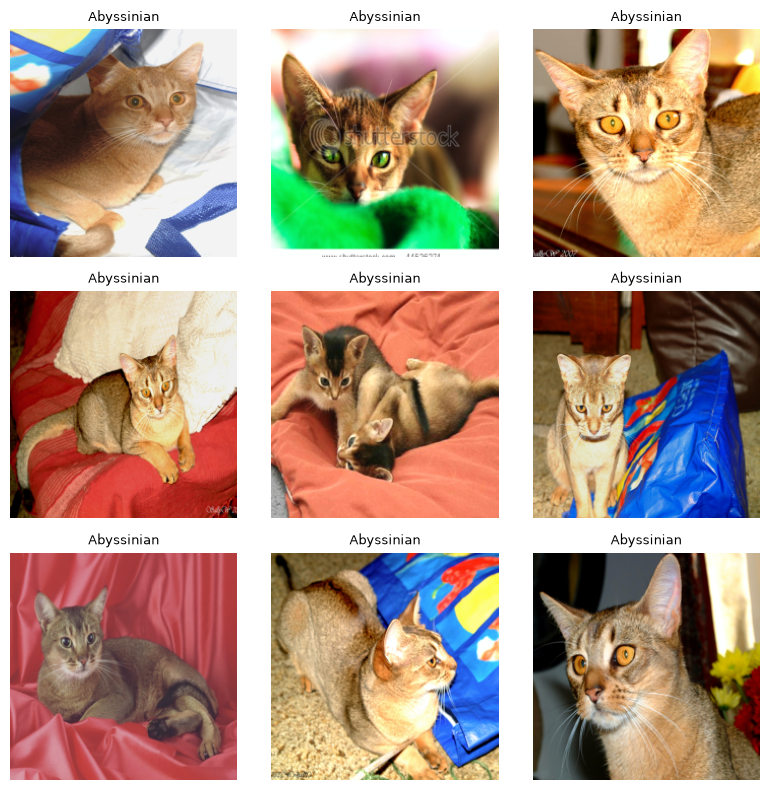

In [12]:
# 데이터 시각화
def imshow(img):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    npimg = img.numpy().transpose(1, 2, 0)   # (C, H, W) -> (H, W, C)
    npimg = np.clip(std * npimg + mean, 0, 1)
    return npimg

def show_samples(dataset, n_images=9):
    fig, axes = plt.subplots(3, 3, figsize=(8, 8))
    axes = axes.flatten()
    for i in range(n_images):
        img, label = dataset[i]
        axes[i].imshow(imshow(img))
        axes[i].set_title(dataset.classes[label], fontsize=9)
        axes[i].axis("off")
    plt.tight_layout()
    plt.show()

show_samples(trainset)

## 학습 (Training)

### Hyper Parameter 설정
| 항목 | 값 |
|---|---|
| Epochs | 20 |
| Batch size | 32 |
| Optimizer | SGD |
| Learning rate | 0.01 |
| Momentum | 0.9 |
| Weight decay | 1e-4 |
| lr_scheduler | CosineAnnealingLR |
| Loss | CrossEntropyLoss |
| Random seed | 42 |
| Device | CUDA (GPU) |

In [33]:
EPOCHS = 20
criterion = nn.CrossEntropyLoss()

def set_seed(seed=42):
    """ 공정한 비교를 위한 시드 고정 """
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def train_model(model, trainloader, testloader, epochs=EPOCHS, lr=1e-4, optimizer=None, name="model"):
    model = model.to(device)
    if optimizer is None:
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    # 학습 과정 저장
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        # ===== 학습 =====
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / total
        train_acc = 100.0 * correct / total

        # ===== 검증 =====
        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in testloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                v_loss += loss.item() * inputs.size(0)
                _, predicted = outputs.max(1)
                v_total += labels.size(0)
                v_correct += (predicted == labels).sum().item()

        val_loss = v_loss / v_total
        val_acc = 100.0 * v_correct / v_total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        current_lr = optimizer.param_groups[0]["lr"]
        print(f"[{name}] Epoch {epoch + 1:2d}/{epochs}  "
              f"train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  "
              f"train_acc={train_acc:5.2f}%  val_acc={val_acc:5.2f}%  lr={current_lr}")

        scheduler.step()  # 매 epoch 끝에 learning rate 감쇠

    return history

In [17]:
# scratch ResNet-50 (사전학습 X)
# set_seed(42)
# baseline = build_resnet50(num_classes=NUM_CLASSES)
# histories["Baseline"] = train_model(baseline, trainloader, testloader, name="Baseline")

[Baseline] Epoch  1/20  train_loss=4.1154  val_loss=3.7416  train_acc= 2.42%  val_acc= 3.03%  lr=0.0100
[Baseline] Epoch  2/20  train_loss=3.6266  val_loss=3.6647  train_acc= 4.02%  val_acc= 4.42%  lr=0.0099
[Baseline] Epoch  3/20  train_loss=3.5121  val_loss=3.4915  train_acc= 6.17%  val_acc= 6.38%  lr=0.0098
[Baseline] Epoch  4/20  train_loss=3.4291  val_loss=3.4746  train_acc= 6.74%  val_acc= 7.99%  lr=0.0095
[Baseline] Epoch  5/20  train_loss=3.4305  val_loss=3.5224  train_acc= 8.02%  val_acc= 7.03%  lr=0.0090
[Baseline] Epoch  6/20  train_loss=3.3586  val_loss=3.3907  train_acc= 8.61%  val_acc=10.28%  lr=0.0085
[Baseline] Epoch  7/20  train_loss=3.2470  val_loss=3.2554  train_acc=10.98%  val_acc=11.34%  lr=0.0079
[Baseline] Epoch  8/20  train_loss=3.1834  val_loss=3.1312  train_acc=11.98%  val_acc=13.25%  lr=0.0073
[Baseline] Epoch  9/20  train_loss=3.0943  val_loss=3.1495  train_acc=14.16%  val_acc=13.55%  lr=0.0065
[Baseline] Epoch 10/20  train_loss=3.0147  val_loss=3.9072  trai

In [29]:
# Feature Extraction ResNet-50 (사전학습 O)

# discriminative LR 설정
backbone_params = [p for n, p in model.named_parameters() if not n.startswith("fc.")]
head_params     = [p for n, p in model.named_parameters() if n.startswith("fc.")]

optimizer = optim.SGD([
    {"params": backbone_params, "lr": 1e-5},   # 잘 학습된 backbone → 살짝만
    {"params": head_params,     "lr": 1e-3},   # 새 분류기 → 더 크게
], momentum=0.9, weight_decay=1e-4)

set_seed(42)
histories["Feature Extraction"] = train_model(model, trainloader, testloader, optimizer=optimizer, name="Feature Extraction")

[Feature Extraction] Epoch  1/20  train_loss=0.1147  val_loss=0.2386  train_acc=97.04%  val_acc=92.31%  lr=9.755282581475769e-06
[Feature Extraction] Epoch  2/20  train_loss=0.1247  val_loss=0.2402  train_acc=96.44%  val_acc=92.23%  lr=9.695230723205111e-06
[Feature Extraction] Epoch  3/20  train_loss=0.1286  val_loss=0.2399  train_acc=96.03%  val_acc=92.23%  lr=9.516553824444453e-06
[Feature Extraction] Epoch  4/20  train_loss=0.1137  val_loss=0.2434  train_acc=96.88%  val_acc=92.01%  lr=9.223651503435911e-06
[Feature Extraction] Epoch  5/20  train_loss=0.1103  val_loss=0.2363  train_acc=96.74%  val_acc=92.26%  lr=8.823735987409787e-06
[Feature Extraction] Epoch  6/20  train_loss=0.1075  val_loss=0.2403  train_acc=97.01%  val_acc=92.31%  lr=8.326654523614147e-06
[Feature Extraction] Epoch  7/20  train_loss=0.1106  val_loss=0.2398  train_acc=96.88%  val_acc=92.15%  lr=7.744646907406436e-06
[Feature Extraction] Epoch  8/20  train_loss=0.1176  val_loss=0.2382  train_acc=96.71%  val_acc=9

In [30]:
# Phase 1 체크포인트 저장
import os

os.makedirs("checkpoints", exist_ok=True)
ckpt_path = "checkpoints/resnet50_feature_extraction.pth"

fe_hist = histories["Feature Extraction"]
best_val_acc = max(fe_hist["val_acc"])          # 학습 중 관측된 최고 val_acc
last_val_acc = fe_hist["val_acc"][-1]           # 마지막 epoch의 val_acc

torch.save({
    "model_state_dict": model.state_dict(),     # 마지막 epoch 가중치 (best가 아님)
    "history": fe_hist,
    "best_val_acc": best_val_acc,
    "last_val_acc": last_val_acc,
    "num_classes": NUM_CLASSES,
}, ckpt_path)

file_mb = os.path.getsize(ckpt_path) / 1e6
print(f"저장 완료 → {ckpt_path}  ({file_mb:.1f} MB)")
print(f"best val_acc = {best_val_acc:.2f}%  |  last(saved) val_acc = {last_val_acc:.2f}%")

저장 완료 → checkpoints/resnet50_feature_extraction.pth  (95.4 MB)
best val_acc = 92.56%  |  last(saved) val_acc = 92.56%


## Fine-tuning

In [34]:
# 체크포인트 불러오기
# 1) 저장할 때와 동일한 구조를 먼저 만듦 (load_state_dict는 빈 구조가 있어야 채움)
model = models.resnet50(weights=None)          # 가중치는 체크포인트로 덮으므로 None
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_features, 128),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(128, NUM_CLASSES),
)

# 2) 체크포인트 로드
checkpoint = torch.load(ckpt_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(device)
print(f"불러온 체크포인트 best val_acc = {checkpoint['best_val_acc']:.2f}%")

# 3) Fine-tuning을 위해 backbone unfreeze
for param in model.parameters():
    param.requires_grad = True

불러온 체크포인트 best val_acc = 92.56%


In [35]:
# Full Fine-tuning 학습

# discriminative LR 설정
backbone_params = [p for n, p in model.named_parameters() if not n.startswith("fc.")]
head_params     = [p for n, p in model.named_parameters() if n.startswith("fc.")]

optimizer = optim.SGD([
    {"params": backbone_params, "lr": 1e-5},   # 잘 학습된 backbone → 살짝만
    {"params": head_params,     "lr": 1e-3},   # 새 분류기 → 더 크게
], momentum=0.9, weight_decay=1e-4)

set_seed(42)
histories["Full Fine-tuning"] = train_model(model, trainloader, testloader, optimizer=optimizer, name="Full Fine-tuning")

[Full Fine-tuning] Epoch  1/20  train_loss=0.1017  val_loss=0.2369  train_acc=97.36%  val_acc=92.40%  lr=1e-05
[Full Fine-tuning] Epoch  2/20  train_loss=0.1090  val_loss=0.2392  train_acc=96.74%  val_acc=92.34%  lr=9.938441702975689e-06
[Full Fine-tuning] Epoch  3/20  train_loss=0.1128  val_loss=0.2416  train_acc=96.71%  val_acc=92.15%  lr=9.755282581475769e-06
[Full Fine-tuning] Epoch  4/20  train_loss=0.0983  val_loss=0.2417  train_acc=97.31%  val_acc=92.29%  lr=9.45503262094184e-06
[Full Fine-tuning] Epoch  5/20  train_loss=0.0980  val_loss=0.2358  train_acc=97.50%  val_acc=92.48%  lr=9.045084971874738e-06
[Full Fine-tuning] Epoch  6/20  train_loss=0.0969  val_loss=0.2398  train_acc=97.39%  val_acc=92.31%  lr=8.535533905932739e-06
[Full Fine-tuning] Epoch  7/20  train_loss=0.0986  val_loss=0.2377  train_acc=97.42%  val_acc=92.37%  lr=7.938926261462368e-06
[Full Fine-tuning] Epoch  8/20  train_loss=0.1043  val_loss=0.2378  train_acc=97.20%  val_acc=92.31%  lr=7.269952498697736e-06
[

## Ablation Study 결과

In [ ]:
# 학습 곡선 시각화 (train loss / val loss / val accuracy)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for name, h in histories.items():
    axes[0].plot(h["train_loss"], label=name)
    axes[1].plot(h["val_loss"], label=name)
    axes[2].plot(h["val_acc"], label=name)

axes[0].set_title("Train Loss")
axes[1].set_title("Validation Loss")
axes[2].set_title("Validation Accuracy")
axes[0].set_ylabel("loss")
axes[2].set_ylabel("accuracy (%)")
for ax in axes:
    ax.set_xlabel("epoch")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---

## Ablation Study 분석

---

## 실험 기록